# Нормализация датасета Executive.ru


## 1. Импорты и пути


In [134]:
from pathlib import Path
import hashlib
import json
import re
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt


In [135]:
BASE_DIR = Path.cwd()

INPUT_CSV = BASE_DIR / "raw" / "business_case_solutions_ru.csv"
OUTPUT_CSV = BASE_DIR / "clean" / "clean_v1.csv"
OUTPUT_JSONL = BASE_DIR / "clean" / "clean_v1.jsonl"
REPORT_JSON = BASE_DIR / "raw" / "normalization_report.json"

print("INPUT: ", INPUT_CSV)
print("OUTPUT:", OUTPUT_CSV)


INPUT:  c:\Users\Дарья\Documents\programming_projects\alfacasebot\alfacasebot\ml\training\data\solution_evaluation\raw\business_case_solutions_ru.csv
OUTPUT: c:\Users\Дарья\Documents\programming_projects\alfacasebot\alfacasebot\ml\training\data\solution_evaluation\clean\clean_v1.csv


## 2. Загрузка CSV в DataFrame


In [136]:
frame = pd.read_csv(
    INPUT_CSV,
    dtype=str,
    keep_default_na=False,
    encoding="utf-8-sig",
)
input_hash = hashlib.sha256(INPUT_CSV.read_bytes()).hexdigest()
print(f"Строк во входном CSV: {len(frame)}")
print(f"Уникальных кейсов: {frame['case_id'].nunique()}")
print("needs_review до нормализации:", frame["needs_review"].str.casefold().eq("true").sum())
print("SHA-256 input:", input_hash)


Строк во входном CSV: 409
Уникальных кейсов: 122
needs_review до нормализации: 35
SHA-256 input: a146cbd6b6c881c7485d574b5f5f9a445ee046874b28494c12ebfd2287bf4385


## 3. Предварительный анализ исходных данных



### 3.1. Размер, пустые значения и дубликаты


In [137]:
empty_values = frame.eq("").sum().sort_values(ascending=False)
duplicate_solution_texts = int(frame["solution_text"].duplicated(keep=False).sum())
review_mask = frame["needs_review"].str.casefold().eq("true")

dataset_overview = pd.Series(
    {
        "rows": len(frame),
        "columns": len(frame.columns),
        "unique_cases": frame["case_id"].nunique(),
        "unique_solution_pages": frame["solution_page_url"].replace("", pd.NA).nunique(),
        "winner_rows": frame["is_winner"].str.casefold().eq("true").sum(),
        "needs_review_rows": review_mask.sum(),
        "exact_duplicate_solution_rows": duplicate_solution_texts,
    },
    name="value",
)
dataset_overview.to_frame()


,value
rows,409
columns,22
unique_cases,122
unique_solution_pages,122
winner_rows,89
needs_review_rows,35
exact_duplicate_solution_rows,0


In [138]:
empty_values[empty_values.gt(0)].rename("empty_values").to_frame()

,empty_values
score_validity,409
score_sources,409
score_analysis,409
score_structure,409
score_logic,409
solution_author_raw,7


### 3.2. Диагностика текста


In [139]:
solution_text = frame["solution_text"]
case_text = frame["case_text"]

text_diagnostics = pd.Series(
    {
        "solution_rows_with_crlf_or_cr": solution_text.str.contains(r"\r", regex=True).sum(),
        "solution_rows_with_nbsp": solution_text.str.contains("\xa0", regex=False).sum(),
        "solution_rows_with_repeated_blank_lines": solution_text.str.contains(
            r"\n[ \t]*\n(?:[ \t]*\n)+", regex=True
        ).sum(),
        "solution_rows_with_judging_footer": solution_text.str.contains(
            "Как оценивались бизнес-решения", regex=False
        ).sum(),
        "solution_rows_with_authors_footer": solution_text.str.contains(
            "Авторы самых интересных решений", regex=False
        ).sum(),
        "solution_rows_with_image_footer": solution_text.str.contains(
            r"Фото(?:\s+в\s+анонсе)?\s*:|Источник\s+изображения\s*:",
            case=False,
            regex=True,
        ).sum(),
        "case_rows_with_image_footer": case_text.str.contains(
            r"Фото(?:\s+в\s+анонсе)?\s*:|Источник\s+изображения\s*:",
            case=False,
            regex=True,
        ).sum(),
        "case_rows_with_submission_instruction": case_text.str.contains(
            r"Присылайте\s+ваши\s+решения|Отправьте\s+свое\s+решение",
            case=False,
            regex=True,
        ).sum(),
    },
    name="rows",
)

text_diagnostics.to_frame()


,rows
solution_rows_with_crlf_or_cr,0
solution_rows_with_nbsp,0
solution_rows_with_repeated_blank_lines,0
solution_rows_with_judging_footer,1
solution_rows_with_authors_footer,2
solution_rows_with_image_footer,17
case_rows_with_image_footer,18
case_rows_with_submission_instruction,4


### 3.3. Кейсы, требующие структурной обработки


In [140]:
structural_cases = pd.DataFrame(
    [
        ("1982396", "в одной строке находятся решения Бориса Ишкина и Сергея Сидорина"),
        ("928046", "три пронумерованных победителя находятся в одной строке"),
        ("838363", "три победителя находятся в одной combined-строке"),
        ("778804", "одно решение ошибочно разделено на две строки"),
        ("1982392", "одно решение ошибочно разделено на три строки"),
        ("1563139", "одно решение ошибочно разделено на две строки"),
        ("760904", "две строки содержат большие блоки из множества решений"),
        ("721047", "краткий анонс и полные решения находятся в разных строках"),
        ("757665", "названия решений ошибочно распознаны как имена авторов"),
    ],
    columns=["case_id", "observed_problem"],
)
structural_cases["source_rows"] = structural_cases["case_id"].map(
    frame.groupby("case_id", sort=False).size()
)
structural_cases["needs_review_rows"] = structural_cases["case_id"].map(
    frame.loc[review_mask].groupby("case_id", sort=False).size()
).fillna(0).astype(int)

structural_cases

,case_id,observed_problem,source_rows,needs_review_rows
0,1982396,в одной строке находятся решения Бориса Ишкина...,13,0
1,928046,три пронумерованных победителя находятся в одн...,1,1
2,838363,три победителя находятся в одной combined-строке,4,1
3,778804,одно решение ошибочно разделено на две строки,15,1
4,1982392,одно решение ошибочно разделено на три строки,7,0
5,1563139,одно решение ошибочно разделено на две строки,3,0
6,760904,две строки содержат большие блоки из множества...,12,0
7,721047,краткий анонс и полные решения находятся в раз...,9,0
8,757665,названия решений ошибочно распознаны как имена...,22,0


In [141]:
frame.loc[
        review_mask,
        ["case_id", "solution_index", "solution_title", "solution_author_raw", "parser_mode"],
    ].reset_index(drop=True)

,case_id,solution_index,solution_title,solution_author_raw,parser_mode
0,1834665,1,Решение победителя:,,html_generic_section
1,1829328,1,Решение победителя:,Геннадий Берешполов,html_generic_section
2,1715528,1,ПОБЕДИТЕЛЬ,Андрей Мешков,html_generic_section
3,1690415,1,ПОБЕДИТЕЛЬ,Денис Савин,html_generic_section
4,1673418,1,ПОБЕДИТЕЛЬ,Екатерина Щербак,html_generic_section
5,1656803,1,ПОБЕДИТЕЛЬ,Станислав Лазарев,html_generic_section
6,1636770,1,Победитель,Герман Милякин,html_generic_section
7,1615688,1,ПОБЕДИТЕЛЬ,,html_generic_section
8,1593296,1,ПОБЕДИТЕЛЬ,,html_generic_section
9,1578505,1,ПОБЕДИТЕЛЬ,Мария Пасынкова,html_generic_section


### 3.4. Визуализация исходного датасета


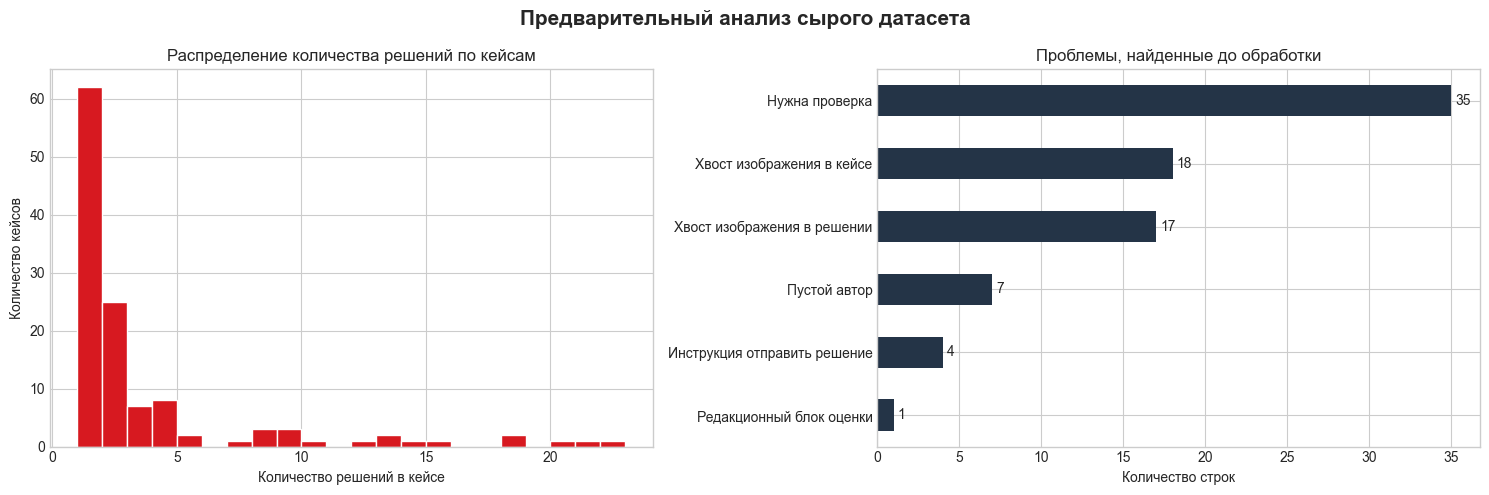

In [142]:
plt.style.use("seaborn-v0_8-whitegrid")

solutions_per_case = frame.groupby("case_id", sort=False).size()
quality_signals = pd.Series(
    {
        "Нужна проверка": int(review_mask.sum()),
        "Пустой автор": int(frame["solution_author_raw"].eq("").sum()),
        "Хвост изображения в решении": int(text_diagnostics["solution_rows_with_image_footer"]),
        "Хвост изображения в кейсе": int(text_diagnostics["case_rows_with_image_footer"]),
        "Инструкция отправить решение": int(
            text_diagnostics["case_rows_with_submission_instruction"]
        ),
        "Редакционный блок оценки": int(
            text_diagnostics["solution_rows_with_judging_footer"]
        ),
    }
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(
    solutions_per_case,
    bins=range(1, int(solutions_per_case.max()) + 2),
    color="#d71920",
    edgecolor="white",
)
axes[0].set_title("Распределение количества решений по кейсам")
axes[0].set_xlabel("Количество решений в кейсе")
axes[0].set_ylabel("Количество кейсов")

quality_signals.plot.barh(ax=axes[1], color="#243447")
axes[1].set_title("Проблемы, найденные до обработки")
axes[1].set_xlabel("Количество строк")
axes[1].set_ylabel("")
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)

fig.suptitle("Предварительный анализ сырого датасета", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()


## 4. Константы обработки и проверка схемы


In [143]:
EXPECTED_FIELDS = [
    "source_site", "language", "case_id", "case_title", "case_text",
    "case_url", "solution_page_id", "solution_page_url", "solution_index",
    "solution_title", "solution_author_raw", "solution_text", "is_winner",
    "parser_mode", "case_parser_mode", "needs_review", "retrieved_at",
    "score_logic", "score_structure", "score_analysis", "score_sources",
    "score_validity",
]

SPACE_RE = re.compile(r"[ \t]+")
MULTI_BLANK_RE = re.compile(r"\n[ \t]*\n(?:[ \t]*\n)+")
NORMALIZE_DEDUP_RE = re.compile(r"[^a-zа-яё0-9]+")
TRAILING_CUT_MARKERS = (
    "Как оценивались бизнес-решения",
    "Авторы самых интересных решений",
)
PHOTO_TAIL_RE = re.compile(
    r"(?:\n\s*)+(?:Фото(?:\s+в\s+анонсе)?|Источник\s+изображения)\s*:[^\n]*(?:\n.*)?\Z",
    re.IGNORECASE | re.DOTALL,
)
CASE_ADMIN_TAIL_RE = re.compile(
    r"(?:\n\s*)+(?:Присылайте\s+ваши\s+решения\b.*|Отправьте\s+свое\s+решение\b.*)\Z",
    re.IGNORECASE | re.DOTALL,
)

# Проверяем схему после анализа и до начала преобразований
fields = frame.columns.tolist()
missing = [field for field in EXPECTED_FIELDS if field not in fields]
if missing:
    raise ValueError(f"В CSV отсутствуют поля: {', '.join(missing)}")



## 5. Переиспользуемые операции


`strip_editorial_tail`


In [144]:
def strip_editorial_tail(text: str) -> tuple[str, list[str]]:
    text = text.strip()
    removed = []
    for marker in TRAILING_CUT_MARKERS:
        match = re.search(rf"(?mi)^\s*{re.escape(marker)}\s*$", text)
        if match:
            text = text[: match.start()].rstrip()
            removed.append(marker)

    before = text
    text = PHOTO_TAIL_RE.sub("", text).rstrip()
    if text != before:
        removed.append("image_footer")
    return text, removed


`merge_rows`


In [145]:
def merge_rows(
    base: pd.Series,
    additions: list[tuple[str, pd.Series]],
    *,
    author: str | None = None,
    title: str | None = None,
    winner: bool | None = None,
) -> pd.Series:
    result = base.copy()
    parts = [base["solution_text"].strip()]
    for heading, additional_row in additions:
        if heading:
            parts.append(heading.strip())
        parts.append(additional_row["solution_text"].strip())
    result["solution_text"] = "\n\n".join(part for part in parts if part).strip()
    if author is not None:
        result["solution_author_raw"] = author
    if title is not None:
        result["solution_title"] = title
    if winner is not None:
        result["is_winner"] = "True" if winner else "False"
    result["parser_mode"] = "normalized_merged"
    result["needs_review"] = "False"
    return result


`split_numbered_winners`


In [146]:
def split_numbered_winners(row: pd.Series, authors: list[str]) -> pd.DataFrame:
    lines = row["solution_text"].splitlines()
    starts = []
    for author in authors:
        pattern = re.compile(
            rf"^\s*\d+\.\s+{re.escape(author)}(?:\s*,|\s*:|\s*$)",
            re.IGNORECASE,
        )
        found = [index for index, line in enumerate(lines) if pattern.search(line)]
        if len(found) != 1:
            raise ValueError(f"{row['case_id']}: граница {author!r} найдена {len(found)} раз")
        starts.append((found[0], author))
    starts.sort()

    result = []
    for position, (start, author) in enumerate(starts):
        end = starts[position + 1][0] if position + 1 < len(starts) else len(lines)
        body = "\n".join(lines[start + 1 : end]).strip()
        if len(body) < 100:
            raise ValueError(f"{row['case_id']}: слишком короткий split для {author}")
        new_row = row.copy()
        new_row["solution_title"] = f"Решение {author}"
        new_row["solution_author_raw"] = author
        new_row["solution_text"] = body
        new_row["is_winner"] = "True"
        new_row["parser_mode"] = "normalized_numbered_winner_split"
        new_row["needs_review"] = "False"
        result.append(new_row)
    return pd.DataFrame(result)


`split_curated_blob`


In [147]:
def split_curated_blob(
    row: pd.Series,
    *,
    first_author: str,
    boundaries: list[tuple[str, str]],
    first_heading: str | None = None,
    truncate_before: str | None = None,
) -> pd.DataFrame:
    lines = [line.strip() for line in row["solution_text"].splitlines() if line.strip()]
    end_limit = len(lines)
    if truncate_before is not None:
        positions = [index for index, line in enumerate(lines) if line == truncate_before]
        if len(positions) != 1:
            raise ValueError(
                f"{row['case_id']}: truncate {truncate_before!r} найден {len(positions)} раз"
            )
        end_limit = positions[0]

    boundary_map = defaultdict(list)
    for label, author in boundaries:
        boundary_map[label].append(author)

    occurrences = defaultdict(int)
    starts = [(0, first_author, f"Решение {first_author}")]
    for index, line in enumerate(lines[:end_limit]):
        if line not in boundary_map:
            continue
        occurrence = occurrences[line]
        authors = boundary_map[line]
        author = authors[min(occurrence, len(authors) - 1)]
        occurrences[line] += 1
        starts.append((index, author, line))

    for label, expected_authors in boundary_map.items():
        actual = occurrences[label]
        if actual != len(expected_authors):
            raise ValueError(
                f"{row['case_id']}: граница {label!r}: ожидалось "
                f"{len(expected_authors)}, найдено {actual}"
            )

    starts.sort()
    result = []
    for position, (start, author, label) in enumerate(starts):
        end = starts[position + 1][0] if position + 1 < len(starts) else end_limit
        body_lines = lines[start:end]
        if start != 0:
            body_lines = body_lines[1:]
        body = "\n".join(body_lines).strip()
        if start == 0 and first_heading:
            body = (first_heading + "\n\n" + body).strip()
        if len(body) < 80:
            raise ValueError(f"{row['case_id']}: слишком короткий сегмент {author}: {len(body)}")

        new_row = row.copy()
        new_row["solution_title"] = (
            f"Решение {author}"
            if start == 0
            else (label if label.casefold().startswith("решение ") else f"Решение {label}")
        )
        new_row["solution_author_raw"] = author
        new_row["solution_text"] = body
        new_row["is_winner"] = "False"
        new_row["parser_mode"] = "normalized_curated_split"
        new_row["needs_review"] = "False"
        result.append(new_row)
    return pd.DataFrame(result)


## 6. Общая очистка DataFrame


In [148]:
changes = Counter()
notes = []

# Нормализация переносов, неразрывных пробелов и пустых строк сразу для колонок
for column in ("solution_text", "case_text"):
    frame[column] = (
        frame[column]
        .str.replace("\r\n", "\n", regex=False)
        .str.replace("\r", "\n", regex=False)
        .str.replace("\xa0", " ", regex=False)
        .str.replace(r"[ \t]+", " ", regex=True)
        .str.replace(r" +\n", "\n", regex=True)
        .str.replace(MULTI_BLANK_RE, "\n\n", regex=True)
        .str.strip()
    )

editorial_results = frame["solution_text"].map(strip_editorial_tail)
cleaned_solutions = editorial_results.str[0]
removed_markers = editorial_results.str[1]
solution_changed = cleaned_solutions.ne(frame["solution_text"])
frame.loc[:, "solution_text"] = cleaned_solutions
changes["editorial_tail_cleaned"] = int(solution_changed.sum())
for markers in removed_markers[solution_changed]:
    for marker in markers:
        changes[f"tail_{marker}"] += 1

case_before = frame["case_text"].copy()
case_without_photo = frame["case_text"].str.replace(PHOTO_TAIL_RE, "", regex=True).str.rstrip()
photo_changed = case_without_photo.ne(case_before)
frame.loc[:, "case_text"] = case_without_photo.str.replace(CASE_ADMIN_TAIL_RE, "", regex=True).str.rstrip()
submission_changed = frame["case_text"].ne(case_without_photo)
case_changed = frame["case_text"].ne(case_before)
changes["case_tail_image_footer_rows"] = int(photo_changed.sum())
changes["case_tail_submission_instruction_rows"] = int(submission_changed.sum())
changes["case_text_cleaned_cases"] = int(frame.loc[case_changed, "case_id"].nunique())


## 7. Точечные исправления через маски `.loc`


In [149]:
simple_author_fixes = {
    ("1834665", "1"): "Кипли Мадиев",
    ("1982396", "1"): "Наталья Чехлатова",
    ("973525", "2"): "Иван Феоктистов",
    ("973525", "3"): "Елена Иванова",
    ("973525", "4"): "Евгения Рузаева",
    ("757665", "20"): "Дмитрий Телегин",
    ("757665", "22"): "Юрий Вербовой",
    ("1829328", "2"): "Анастасия Титаева",
    ("876395", "5"): "Юрий Стоколяс",
}
for (case_id, solution_index), author in simple_author_fixes.items():
    mask = frame["case_id"].eq(case_id) & frame["solution_index"].eq(solution_index)
    frame.loc[mask, ["solution_author_raw", "needs_review", "parser_mode"]] = [
        author,
        "False",
        "normalized_manual_fix",
    ]
    changes["author_fixed"] += int(mask.sum())

signature_fixes = {
    ("1615688", "1"): ("Александр Филимонихин", "Александр Филимонихин"),
    ("1593296", "1"): ("Алина Федорова", "Алина Федорова"),
    ("1127856", "1"): ("Сергей Шебек", "Сергей Шебек"),
    ("1829328", "2"): ("Анастасия Титаева", "Анастасия Титаева"),
}
for (case_id, solution_index), (author, prefix) in signature_fixes.items():
    mask = frame["case_id"].eq(case_id) & frame["solution_index"].eq(solution_index)
    for row_index in frame.index[mask]:
        lines = frame.at[row_index, "solution_text"].splitlines()
        first_line = lines[0].strip() if lines else ""
        if not first_line.casefold().startswith(prefix.casefold()):
            raise ValueError(f"Ожидалась подпись {prefix!r}, получено {first_line[:120]!r}")
        frame.at[row_index, "solution_text"] = "\n".join(lines[1:]).strip()
    frame.loc[mask, ["solution_author_raw", "needs_review", "parser_mode"]] = [
        author,
        "False",
        "normalized_manual_fix",
    ]
    changes["signature_removed"] += int(mask.sum())

museum_authors = {
    "1": "Борис Яровой", "2": "Ольга Малашкина", "3": "Александр Будаков",
    "4": "Андрей Куренков", "5": "Сергей Лоханов", "6": "Дарья Захарова",
    "7": "Андрей Геронин", "8": "Ольга Вепрецкая",
}
for solution_index, author in museum_authors.items():
    mask = frame["case_id"].eq("1979833") & frame["solution_index"].eq(solution_index)
    for row_index in frame.index[mask]:
        lines = frame.at[row_index, "solution_text"].splitlines()
        first_line = lines[0].strip() if lines else ""
        if not first_line.casefold().startswith(author.casefold()):
            raise ValueError(f"Ожидалась подпись {author!r}, получено {first_line[:120]!r}")
        remainder = first_line.split(":", 1)[1].strip() if ":" in first_line else ""
        frame.at[row_index, "solution_text"] = "\n".join(
            ([remainder] if remainder else []) + lines[1:]
        ).strip()
    frame.loc[mask, ["solution_author_raw", "needs_review", "parser_mode"]] = [
        author,
        "False",
        "normalized_manual_fix",
    ]
    changes["museum_author_fixed"] += int(mask.sum())


### Остаточные служебные хвосты и склеенные решения

Шесть строк содержат редакционные блоки после завершённого ответа. Ещё в двух строках подряд записаны ответы разных авторов: их важно разделить, а не просто обрезать, чтобы не потерять данные.


In [150]:
tail_fixes = {
    "1923745": "Комментарий автора кейса",
    "1915529": "Комментарий автора кейса",
    "1888897": "Комментарий автора кейса",
    "1794076": "Комментарий автора кейса",
    "1316767": "Все решения кейса, присланные участниками",
    "805220": "Все решения кейса, присланные участниками",
}
for case_id, marker in tail_fixes.items():
    mask = frame["case_id"].eq(case_id) & frame["solution_text"].str.contains(
        marker, regex=False
    )
    if int(mask.sum()) != 1:
        raise ValueError(f"{case_id}: ожидалась одна строка с хвостом {marker!r}")
    frame.loc[mask, "solution_text"] = (
        frame.loc[mask, "solution_text"].str.split(marker, n=1).str[0].str.rstrip()
    )
    frame.loc[mask, "parser_mode"] = "normalized_manual_fix"
    changes["residual_editorial_tail_removed"] += 1

split_specs = {
    "1058936": {
        "marker": "«Игры и уникальные сервисы». Решение Егора Гуторова",
        "title": "Игры и уникальные сервисы",
        "author": "Егор Гуторов",
    },
    "876395": {
        "marker": "Решение кейса предлагает Артем Голышев:",
        "title": "Решение кейса предлагает Артем Голышев",
        "author": "Артем Голышев",
    },
}
split_rows = []
for case_id, spec in split_specs.items():
    mask = frame["case_id"].eq(case_id) & frame["solution_text"].str.contains(
        spec["marker"], regex=False
    )
    if int(mask.sum()) != 1:
        raise ValueError(f"{case_id}: ожидалась одна склеенная строка")
    row_index = frame.index[mask][0]
    first_text, second_text = frame.at[row_index, "solution_text"].split(
        spec["marker"], 1
    )
    if len(first_text.strip()) < 80 or len(second_text.strip()) < 80:
        raise ValueError(f"{case_id}: одна из частей склейки слишком короткая")
    frame.at[row_index, "solution_text"] = first_text.strip()
    frame.at[row_index, "parser_mode"] = "normalized_manual_fix"
    new_row = frame.loc[row_index].copy()
    new_row["solution_title"] = spec["title"]
    new_row["solution_author_raw"] = spec["author"]
    new_row["solution_text"] = second_text.strip()
    new_row["needs_review"] = "False"
    new_row["parser_mode"] = "normalized_manual_split"
    split_rows.append(new_row)
    changes["merged_solution_split"] += 1

frame = pd.concat([frame, pd.DataFrame(split_rows)], ignore_index=True)


## 8. Группировка по кейсам


In [151]:
case_order = frame["case_id"].drop_duplicates().tolist()
case_frames = {
    case_id: group.reset_index(drop=True)
    for case_id, group in frame.groupby("case_id", sort=False)
}


### Скрытое решение в кейсе 1982396


In [152]:
group = case_frames["1982396"]
target_position = group.index[group["solution_index"].eq("2")].item()
split = split_curated_blob(
    group.loc[target_position],
    first_author="Борис Ишкин",
    boundaries=[("Решения Сергея Сидорина", "Сергей Сидорин")],
)
if len(split) != 2:
    raise ValueError("1982396: ожидалось два решения в строке Бориса Ишкина")
split.loc[:, "solution_title"] = ["Решение Бориса Ишкина", "Решение Сергея Сидорина"]
case_frames["1982396"] = pd.concat(
    [group.iloc[:target_position], split, group.iloc[target_position + 1 :]],
    ignore_index=True,
)
changes["hidden_solution_recovered"] += 1


### Объединённые победители в кейсе 928046


In [153]:
group = case_frames["928046"]
if len(group) != 1:
    raise ValueError(f"928046: ожидалась 1 строка, получено {len(group)}")
case_frames["928046"] = split_numbered_winners(
    group.iloc[0],
    ["Александр Погорелов", "Ольга Ермолаева", "Александр Сивоплясов"],
).reset_index(drop=True)
changes["combined_winner_rows_split"] += 1
changes["rows_created_by_winner_split"] += 2


### Победители в кейсе 838363


In [154]:
group = case_frames["838363"]
combined = group.loc[group["solution_index"].eq("1")]
if len(combined) != 1:
    raise ValueError("838363: не найдена единственная combined-строка")
split = split_numbered_winners(
    combined.iloc[0],
    ["Анжелика Швец", "Михаил Петровец", "Виктор Шапкин"],
)
case_frames["838363"] = pd.concat(
    [split, group.loc[~group["solution_index"].eq("1")]],
    ignore_index=True,
)
changes["combined_winner_rows_split"] += 1
changes["rows_created_by_winner_split"] += 2


### Объединение строк кейса 778804


In [155]:
group = case_frames["778804"].copy()
position2 = group.index[group["solution_index"].eq("2")].item()
position3 = group.index[group["solution_index"].eq("3")].item()
group.loc[position2] = merge_rows(
    group.loc[position2],
    [("Решение кейса:", group.loc[position3])],
    author="Константин Кузьмищенко",
    title="Решение Константина Кузьмищенко",
)
case_frames["778804"] = group.drop(index=position3).reset_index(drop=True)
changes["internal_heading_rows_merged"] += 1
changes["rows_removed_by_merge"] += 1


### Объединение строк кейса 1982392


In [156]:
group = case_frames["1982392"].copy()
positions = {
    index: group.index[group["solution_index"].eq(index)].item()
    for index in ("5", "6", "7")
}
group.loc[positions["5"]] = merge_rows(
    group.loc[positions["5"]],
    [
        ("Решение задачи «Взаимоотношения сторон»", group.loc[positions["6"]]),
        ("Решение задачи «Сохранить и развить бизнес»", group.loc[positions["7"]]),
    ],
    author="Анатолий Кондратов",
    title="Решение Анатолия Кондратова",
)
case_frames["1982392"] = group.drop(index=[positions["6"], positions["7"]]).reset_index(drop=True)
changes["internal_heading_rows_merged"] += 2
changes["rows_removed_by_merge"] += 2


### Объединение строк кейса 1563139


In [157]:
group = case_frames["1563139"].copy()
position1 = group.index[group["solution_index"].eq("1")].item()
position2 = group.index[group["solution_index"].eq("2")].item()
group.loc[position1] = merge_rows(
    group.loc[position1],
    [("Решение может заключаться в следующих действиях:", group.loc[position2])],
    author="Сергей Бурых",
    title="Решение Сергея Бурых",
)
case_frames["1563139"] = group.drop(index=position2).reset_index(drop=True)
changes["internal_heading_rows_merged"] += 1
changes["rows_removed_by_merge"] += 1


### Большие блоки кейса 760904


In [158]:
group = case_frames["760904"].copy()

position2 = group.index[group["solution_index"].eq("2")].item()
heading = "Комментарии экспертов:"
match = re.search(rf"(?mi)^\s*{re.escape(heading)}\s*$", group.at[position2, "solution_text"])
if not match:
    raise ValueError(f"Не найден ожидаемый заголовок для обрезки: {heading!r}")
group.at[position2, "solution_text"] = group.at[position2, "solution_text"][: match.start()].rstrip()
changes["expert_commentary_trimmed"] += 1

winner_mask = group["solution_index"].isin(["1", "2"])
group.loc[winner_mask, "is_winner"] = "True"
changes["winner_flag_fixed"] += int(winner_mask.sum())

manual_fixes = {
    "9": ("Эдуард Бурчаганов", "Решение Эдуарда Бурчаганова: Возможности"),
    "10": ("Тимур Хвалько", "Решение Тимура Хвалько: Бизнес—Игра"),
}
for solution_index, (author, title) in manual_fixes.items():
    mask = group["solution_index"].eq(solution_index)
    group.loc[mask, ["solution_author_raw", "solution_title", "parser_mode"]] = [
        author,
        title,
        "normalized_manual_fix",
    ]
    changes["author_fixed"] += int(mask.sum())

blob11 = group.loc[group["solution_index"].eq("11")].iloc[0]
blob12 = group.loc[group["solution_index"].eq("12")].iloc[0]

boundaries11 = [
    ("Михаил Прошлецов", "Михаил Прошлецов"),
    ("Константин Кузьмищенко «Тройной выигрыш» (Win—Win—Win)", "Константин Кузьмищенко"),
    ("Константин Мехнин Сохранить стабильность", "Константин Мехнин"),
    ("Елена Власова Принципиальные переговоры", "Елена Власова"),
    ("Анатолий Модяев За все надо платить!", "Анатолий Модяев"),
    ("Ирина Седова", "Ирина Седова"),
    ("Евгений Белеуш Аутплейсмент", "Евгений Белеуш"),
    ("Мария Петровская Павел руководитель нового проекта, менеджер по развитию", "Мария Петровская"),
    ("Наталья Коршун Важно сохранить двоих и мотивировать работать плодотворно в будущем", "Наталья Коршун"),
    ("Алевтина Рудник Лучшее в зарождающейся проблеме.", "Алевтина Рудник"),
    ("Мария Храпко Индивидуальная лояльность или решение вам подскажет сам сотрудник", "Мария Храпко"),
    ("Евгений Бридский Человечный подход", "Евгений Бридский"),
]


split11 = split_curated_blob(
    blob11,
    first_author="Екатерина Нестерова",
    boundaries=boundaries11,
    first_heading=blob11["solution_title"],
    truncate_before="Оксана Сергеева",
)

boundaries12 = [
    ("Надежда Грибовская Решение с видом на будущее", "Надежда Грибовская"),
    ("Вячеслав Колосов", "Вячеслав Колосов"),
    ("Андрей Денисов", "Андрей Денисов"),
    ("Юлия Докучаева", "Юлия Докучаева"),
    ("Елена Козлова", "Елена Козлова"),
    ("Андрей Трякин Ответ на кейс", "Андрей Трякин"),
    ("Денис Нитусов", "Денис Нитусов"),
    ("Константин Глазюков", "Константин Глазюков"),
    ("Руслан Ахтямов", "Руслан Ахтямов"),
    ("Елена Еременко", "Елена Еременко"),
    ("Наталья Булбук", "Наталья Булбук"),
    ("Юлия Татаринцева", "Юлия Татаринцева"),
    ("Роман Селютин Возврат Марии и перспектива для Павла", "Роман Селютин"),
    ("Елена Еременко", "Елена Еременко"),
    ("Алексей Лебедев Катализатор", "Алексей Лебедев"),
]


split12 = split_curated_blob(
    blob12,
    first_author="Оксана Сергеева",
    boundaries=boundaries12,
    first_heading=blob12["solution_title"],
)

duplicate_elena = split12["solution_author_raw"].eq("Елена Еременко") & split12.duplicated(
    subset=["solution_author_raw"], keep="first"
)
changes["near_duplicate_solution_removed"] += int(duplicate_elena.sum())
split12 = split12.loc[~duplicate_elena]

case_frames["760904"] = pd.concat(
    [group.loc[~group["solution_index"].isin(["11", "12"])], split11, split12],
    ignore_index=True,
)
changes["large_solution_blobs_split"] += 2
changes["rows_created_by_blob_split"] += len(split11) + len(split12) - 2


### Полные решения кейса 721047


In [159]:
group = case_frames["721047"].copy()
full_blob = group.loc[group["solution_index"].eq("9")].iloc[0]
split = split_curated_blob(
    full_blob,
    first_author="Андрей Каслин",
    boundaries=[("Валентин Мерзликин", "Валентин Мерзликин")],
    first_heading=full_blob["solution_title"],
)
if len(split) != 2:
    raise ValueError("721047: ожидалось два решения в full blob")
split.iloc[0, split.columns.get_indexer(["is_winner", "solution_title", "parser_mode"])] = [
    "True", "Решение Андрей Каслин", "normalized_full_version"
]
split.iloc[1, split.columns.get_indexer(["is_winner", "solution_title", "parser_mode"])] = [
    "False", "Решение Валентин Мерзликин", "normalized_curated_split"
]
position2 = group.index[group["solution_index"].eq("2")].item()
position9 = group.index[group["solution_index"].eq("9")].item()
group.loc[position2] = split.iloc[0]
group.loc[position9] = split.iloc[1]
case_frames["721047"] = group.reset_index(drop=True)
changes["summary_replaced_by_full_solution"] += 1
changes["duplicate_summary_removed"] += 1
changes["hidden_solution_recovered"] += 1


### Исправления кейса 757665


In [160]:
group = case_frames["757665"].copy()
winner_mask = group["solution_index"].eq("1")
group.loc[winner_mask, "is_winner"] = "True"
changes["winner_flag_fixed"] += int(winner_mask.sum())

manual_fixes = {
    "20": ("Дмитрий Телегин", "Решение Дмитрия Телегина: Сблизиться Нельзя Отдаляться"),
    "22": ("Юрий Вербовой", "Решение Юрия Вербового: Креатор"),
}
for solution_index, (author, title) in manual_fixes.items():
    mask = group["solution_index"].eq(solution_index)
    group.loc[mask, ["solution_author_raw", "solution_title", "parser_mode"]] = [
        author,
        title,
        "normalized_manual_fix",
    ]
    changes["author_fixed"] += int(mask.sum())
case_frames["757665"] = group


## 9. Финальная сборка


In [161]:
structural_problem_cases = {"928046", "838363", "778804", "760904"}
for case_id, group in case_frames.items():
    review_mask = group["needs_review"].str.casefold().eq("true")
    if case_id in structural_problem_cases and review_mask.any():
        raise ValueError(f"{case_id}: после структурной правки остался needs_review")
    if review_mask.any():
        normalized_mode = group.loc[review_mask, "parser_mode"].str.startswith("normalized_")
        replacement_mode = group.loc[review_mask, "parser_mode"].where(
            normalized_mode,
            "normalized_reviewed_valid",
        )
        group.loc[review_mask, "needs_review"] = "False"
        group.loc[review_mask, "parser_mode"] = replacement_mode
        changes["review_flag_cleared_after_manual_check"] += int(review_mask.sum())

frame = pd.concat([case_frames[case_id] for case_id in case_order], ignore_index=True)

post_cleanup = frame["solution_text"].map(strip_editorial_tail)
frame.loc[:, "solution_text"] = post_cleanup.str[0]
for markers in post_cleanup.str[1]:
    for marker in markers:
        changes[f"post_transform_tail_{marker}"] += 1

page_key = frame["solution_page_url"].where(frame["solution_page_url"].ne(""))
page_key = page_key.fillna(frame["solution_page_id"].where(frame["solution_page_id"].ne("")))
page_key = page_key.fillna(frame["case_id"])
frame.loc[:, "solution_index"] = frame.groupby(page_key, sort=False).cumcount().add(1).astype(str)


## 10. Валидация и отчёт


In [162]:
errors = []
known_bad_author_fragments = (
    "данной ситуации видится мне так", "лежит в плоскости двух аспектов",
    "проблемы увеличения продаж компании osg", "может заключаться в следующих действиях",
    "задачи «взаимоотношения сторон»", "задачи «сохранить и развить бизнес»",
    "сблизиться нельзя отдаляться", "задачи – креатор",
)
forbidden_solution_fragments = (
    "Комментарий автора кейса",
    "Все решения кейса, присланные участниками",
    "«Игры и уникальные сервисы». Решение Егора Гуторова",
    "Решение кейса предлагает Артем Голышев:",
)

for row_index, row in frame.iterrows():
    text = row["solution_text"].strip()
    author = row["solution_author_raw"].strip()
    identifier = f"{row['case_id']}#{row['solution_index']}"
    if len(text) < 80:
        errors.append(f"{identifier}: solution_text < 80")
    if row["needs_review"].casefold() == "true":
        errors.append(f"{identifier}: needs_review=True")
    if any(fragment in author.casefold() for fragment in known_bad_author_fragments):
        errors.append(f"{identifier}: bad author {author!r}")
    if "Фото в анонсе:" in text:
        errors.append(f"{identifier}: photo footer")
    if "Как оценивались бизнес-решения" in text:
        errors.append(f"{identifier}: judging footer")
    if "Комментарии экспертов:" in text:
        errors.append(f"{identifier}: expert commentary")
    for fragment in forbidden_solution_fragments:
        if fragment in text:
            errors.append(f"{identifier}: residual fragment {fragment!r}")
    if re.search(r"Фото(?: в анонсе)?\s*:", row["case_text"], re.IGNORECASE):
        errors.append(f"{identifier}: case photo footer")
    if re.search(
        r"Присылайте\s+ваши\s+решения|Отправьте\s+свое\s+решение",
        row["case_text"],
        re.IGNORECASE,
    ):
        errors.append(f"{identifier}: case submission instruction")

if errors:
    raise ValueError("Нормализация не прошла валидацию:\n- " + "\n- ".join(errors[:30]))

normalized_text = (
    frame["solution_text"]
    .str.casefold()
    .str.replace(NORMALIZE_DEDUP_RE, " ", regex=True)
    .str.strip()
)
duplicate_count = int(normalized_text.duplicated(keep="first").sum())

report = {
    "input_rows": int(len(pd.read_csv(INPUT_CSV, dtype=str, keep_default_na=False))),
    "output_rows": len(frame),
    "unique_cases": int(frame["case_id"].nunique()),
    "winner_rows": int(frame["is_winner"].str.casefold().eq("true").sum()),
    "needs_review_rows": int(frame["needs_review"].str.casefold().eq("true").sum()),
    "exact_duplicate_texts_remaining": duplicate_count,
    "changes": dict(sorted(changes.items())),
    "notes": notes,
}
normalized_frame = frame.loc[:, fields].copy()


In [163]:
print(f"409 -> {len(normalized_frame)} строк")
print("Уникальных кейсов:", report["unique_cases"])
print("Победителей:", report["winner_rows"])
print("needs_review:", report["needs_review_rows"])
print("Точных дубликатов:", report["exact_duplicate_texts_remaining"])
print("\nИзменения:")
for key, value in report["changes"].items():
    print(f"  {key}: {value}")


409 -> 438 строк
Уникальных кейсов: 122
Победителей: 97
needs_review: 0
Точных дубликатов: 0

Изменения:
  author_fixed: 13
  case_tail_image_footer_rows: 18
  case_tail_submission_instruction_rows: 4
  case_text_cleaned_cases: 18
  combined_winner_rows_split: 2
  duplicate_summary_removed: 1
  editorial_tail_cleaned: 19
  expert_commentary_trimmed: 1
  hidden_solution_recovered: 2
  internal_heading_rows_merged: 4
  large_solution_blobs_split: 2
  merged_solution_split: 2
  museum_author_fixed: 8
  near_duplicate_solution_removed: 1
  residual_editorial_tail_removed: 6
  review_flag_cleared_after_manual_check: 28
  rows_created_by_blob_split: 26
  rows_created_by_winner_split: 4
  rows_removed_by_merge: 4
  signature_removed: 4
  summary_replaced_by_full_solution: 1
  tail_image_footer: 16
  tail_Авторы самых интересных решений: 2
  tail_Как оценивались бизнес-решения: 1
  winner_flag_fixed: 3


## 11. Визуализация результата обработки


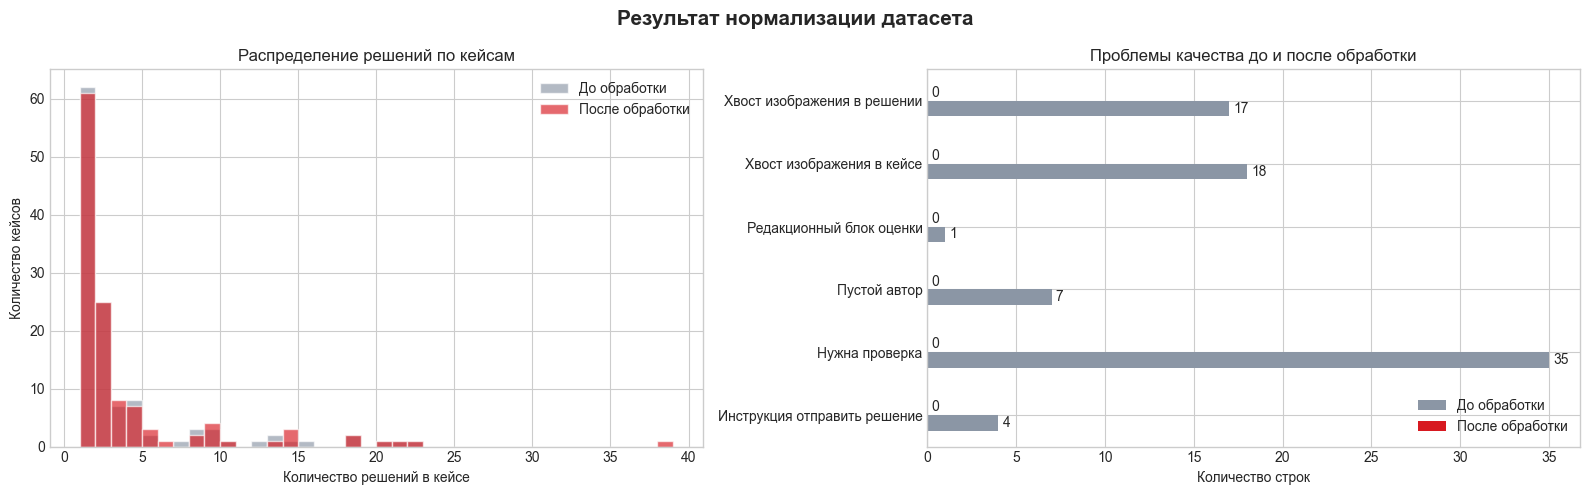

,До обработки,После обработки
Инструкция отправить решение,4,0
Нужна проверка,35,0
Пустой автор,7,0
Редакционный блок оценки,1,0
Хвост изображения в кейсе,18,0
Хвост изображения в решении,17,0


In [164]:
normalized_solutions_per_case = normalized_frame.groupby("case_id", sort=False).size()

after_quality_signals = pd.Series(
    {
        "Нужна проверка": int(
            normalized_frame["needs_review"].str.casefold().eq("true").sum()
        ),
        "Пустой автор": int(normalized_frame["solution_author_raw"].eq("").sum()),
        "Хвост изображения в решении": int(
            normalized_frame["solution_text"].str.contains(
                r"Фото(?:\s+в\s+анонсе)?\s*:|Источник\s+изображения\s*:",
                case=False,
                regex=True,
            ).sum()
        ),
        "Хвост изображения в кейсе": int(
            normalized_frame["case_text"].str.contains(
                r"Фото(?:\s+в\s+анонсе)?\s*:|Источник\s+изображения\s*:",
                case=False,
                regex=True,
            ).sum()
        ),
        "Инструкция отправить решение": int(
            normalized_frame["case_text"].str.contains(
                r"Присылайте\s+ваши\s+решения|Отправьте\s+свое\s+решение",
                case=False,
                regex=True,
            ).sum()
        ),
        "Редакционный блок оценки": int(
            normalized_frame["solution_text"].str.contains(
                "Как оценивались бизнес-решения",
                regex=False,
            ).sum()
        ),
    }
)

quality_comparison = pd.DataFrame(
    {
        "До обработки": quality_signals,
        "После обработки": after_quality_signals,
    }
).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

max_solutions = int(max(solutions_per_case.max(), normalized_solutions_per_case.max()))
bins = range(1, max_solutions + 2)
axes[0].hist(
    solutions_per_case,
    bins=bins,
    alpha=0.65,
    label="До обработки",
    color="#8b96a5",
    edgecolor="white",
)
axes[0].hist(
    normalized_solutions_per_case,
    bins=bins,
    alpha=0.65,
    label="После обработки",
    color="#d71920",
    edgecolor="white",
)
axes[0].set_title("Распределение решений по кейсам")
axes[0].set_xlabel("Количество решений в кейсе")
axes[0].set_ylabel("Количество кейсов")
axes[0].legend()

quality_comparison.plot.barh(
    ax=axes[1],
    color=["#8b96a5", "#d71920"],
)
axes[1].set_title("Проблемы качества до и после обработки")
axes[1].set_xlabel("Количество строк")
axes[1].set_ylabel("")
axes[1].legend(loc="lower right")
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)

fig.suptitle("Результат нормализации датасета", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

quality_comparison


## 12. Sanity-check


In [165]:
assert not normalized_frame.empty, "Итоговый датасет пуст"
assert normalized_frame["case_id"].nunique() == report["unique_cases"]
assert normalized_frame["needs_review"].str.casefold().eq("false").all()
assert normalized_frame["solution_author_raw"].str.strip().ne("").all()
assert normalized_frame["solution_text"].str.strip().str.len().ge(80).all()

page_key = normalized_frame["solution_page_url"].where(normalized_frame["solution_page_url"].ne(""))
page_key = page_key.fillna(
    normalized_frame["solution_page_id"].where(normalized_frame["solution_page_id"].ne(""))
)
page_key = page_key.fillna(normalized_frame["case_id"])
expected_indices = normalized_frame.groupby(page_key, sort=False).cumcount().add(1).astype(str)
assert normalized_frame["solution_index"].equals(expected_indices), "Непоследовательные solution_index"
print("Sanity-check: OK")


Sanity-check: OK


## 13. Экспорт


In [166]:
normalized_frame.to_csv(
    OUTPUT_CSV,
    index=False,
    encoding="utf-8-sig",
    lineterminator="\r\n",
)
normalized_frame.to_json(
    OUTPUT_JSONL,
    orient="records",
    lines=True,
    force_ascii=False,
)

report["input_sha256"] = hashlib.sha256(INPUT_CSV.read_bytes()).hexdigest()
report["output_sha256"] = hashlib.sha256(OUTPUT_CSV.read_bytes()).hexdigest()
REPORT_JSON.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")

print("CSV:   ", OUTPUT_CSV)
print("JSONL: ", OUTPUT_JSONL)
print("REPORT:", REPORT_JSON)
print("SHA-256 output:", report["output_sha256"])


CSV:    c:\Users\Дарья\Documents\programming_projects\alfacasebot\alfacasebot\ml\training\data\solution_evaluation\clean\clean_v1.csv
JSONL:  c:\Users\Дарья\Documents\programming_projects\alfacasebot\alfacasebot\ml\training\data\solution_evaluation\clean\clean_v1.jsonl
REPORT: c:\Users\Дарья\Documents\programming_projects\alfacasebot\alfacasebot\ml\training\data\solution_evaluation\raw\normalization_report.json
SHA-256 output: d8266262c619633372b23c18b20673fda3f06592414ae509ea7ac98702f0bb2b
